# Lecture 7 Live Demo — Exploratory Data Analysis
## ITDS341 Fundamentals of Data Science

### Scenario
A campus café wants to understand **customer spending and waiting experience** before making any operational changes.

We will use a small synthetic dataset so the demo runs anywhere without downloading external files.

### Guiding questions
1. What does a typical customer visit look like?
2. Which groups appear to differ in spending or waiting time?
3. Which numerical variables move together?
4. Does adding a third variable reveal a hidden subgroup?
5. What can EDA suggest — and what can it **not** prove?

> **Teaching cue:** Keep asking: *What question does this plot answer?*

## 1. Setup and Create the Demo Data

The data are intentionally designed to contain:
- a right-skewed variable,
- a few unusual values,
- different group sizes,
- a relationship that becomes clearer after grouping.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

rng = np.random.default_rng(341)
n = 240

channel = rng.choice(['Counter', 'Mobile'], size=n, p=[0.68, 0.32])
member = rng.choice(['No', 'Yes'], size=n, p=[0.55, 0.45])
daypart = rng.choice(['Morning', 'Lunch', 'Afternoon'], size=n, p=[0.30, 0.45, 0.25])

items = np.clip(rng.poisson(2.2, size=n) + 1, 1, 8)
wait_time = (
    rng.normal(7.5, 2.0, size=n)
    + np.where(channel == 'Counter', 2.0, -1.0)
    + np.where(daypart == 'Lunch', 2.2, 0)
)
wait_time = np.clip(wait_time, 0.5, None)

spend = (
    35
    + items * 22
    + np.where(member == 'Yes', 10, 0)
    + np.where(channel == 'Mobile', 6, 0)
    + rng.gamma(2.0, 10.0, size=n)
)

satisfaction = (
    5.1
    - 0.18 * wait_time
    + np.where(member == 'Yes', 0.25, 0)
    + rng.normal(0, 0.45, size=n)
)
satisfaction = np.clip(satisfaction, 1, 5)

# Add a few unusual observations deliberately
spend[[8, 91, 177]] *= [2.2, 2.8, 2.5]
wait_time[[31, 144]] += [10, 12]

df = pd.DataFrame({
    'channel': channel,
    'member': member,
    'daypart': daypart,
    'items': items,
    'wait_time_min': wait_time.round(1),
    'spend_baht': spend.round(0),
    'satisfaction': satisfaction.round(1)
})

df.head()

,channel,member,daypart,items,wait_time_min,spend_baht,satisfaction
0,Counter,No,Morning,4,7.1,152.0,3.5
1,Counter,No,Afternoon,1,8.5,62.0,3.1
2,Counter,Yes,Afternoon,3,14.2,117.0,2.4
3,Mobile,Yes,Lunch,2,9.9,107.0,4.4
4,Counter,No,Lunch,1,9.3,73.0,3.8


## 2. Data Readiness Check

Before plotting:
- How many rows and columns?
- Any missing values?
- Which columns are numerical vs categorical in **meaning**?

> **Teaching cue:** `dtype` is storage type, not necessarily analytical type.

In [2]:
print("Shape:", df.shape)
display(df.head())
display(df.isna().sum().to_frame("missing"))
display(df.describe(include='all').T)

Shape: (240, 7)


,channel,member,daypart,items,wait_time_min,spend_baht,satisfaction
0,Counter,No,Morning,4,7.1,152.0,3.5
1,Counter,No,Afternoon,1,8.5,62.0,3.1
2,Counter,Yes,Afternoon,3,14.2,117.0,2.4
3,Mobile,Yes,Lunch,2,9.9,107.0,4.4
4,Counter,No,Lunch,1,9.3,73.0,3.8


,missing
channel,0
member,0
daypart,0
items,0
wait_time_min,0
spend_baht,0
satisfaction,0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
channel,240,2,Counter,152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
member,240,2,No,133,NaN,NaN,NaN,NaN,NaN,NaN,NaN
daypart,240,3,Lunch,105,NaN,NaN,NaN,NaN,NaN,NaN,NaN
items,240.0,NaN,NaN,NaN,3.220833,1.462639,1.0,2.0,3.0,4.0,8.0
wait_time_min,240.0,NaN,NaN,NaN,9.414583,3.005601,0.8,7.3,9.5,11.1,23.4
spend_baht,240.0,NaN,NaN,NaN,134.804167,41.661607,60.0,110.75,130.0,155.0,447.0
satisfaction,240.0,NaN,NaN,NaN,3.492083,0.664695,1.6,3.0,3.5,4.0,4.9


### Quick class question
Which of these are:
- numerical continuous,
- numerical discrete,
- categorical nominal?

Ask students before revealing the answer.

**Suggested answer**
- `items`: numerical discrete
- `wait_time_min`, `spend_baht`, `satisfaction`: numerical
- `channel`, `member`, `daypart`: categorical nominal

## 3. Univariate EDA — Categorical Variable

**Question:** How do customers place their orders?

Lecture 6 gave us the summary table.  
Lecture 7 adds the visual form.

,count
channel,
Counter,152
Mobile,88


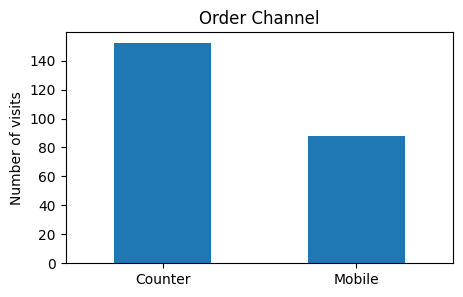

In [3]:
channel_counts = df['channel'].value_counts()
display(channel_counts.to_frame("count"))

ax = channel_counts.plot.bar(figsize=(5, 3))
ax.set_title("Order Channel")
ax.set_xlabel("")
ax.set_ylabel("Number of visits")
plt.xticks(rotation=0)
plt.show()

### What should students say?
Not just: *"Counter is higher."*

Better:
> Counter orders make up the majority of visits in this sample, so raw counts from later comparisons may be dominated by counter customers.

This sets up the idea that **group size matters**.

## 4. Univariate EDA — Numerical Variable

**Question:** What does customer spending look like?

Use both a histogram and a box plot because they answer different questions.

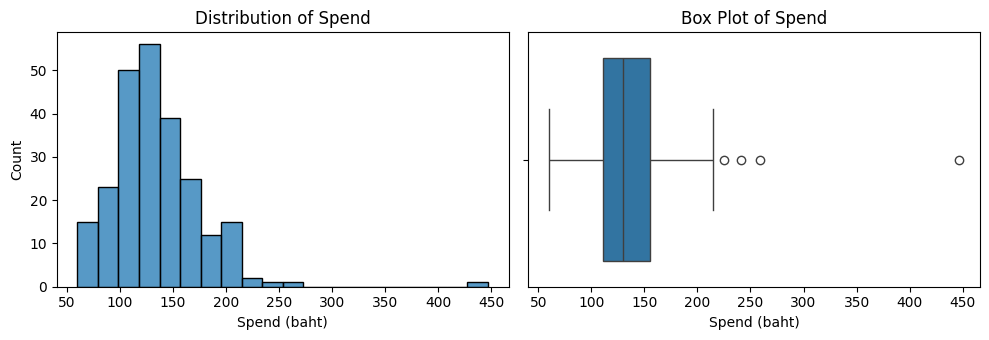

,spend_baht
count,240.0
mean,134.8
std,41.7
min,60.0
25%,110.8
50%,130.0
75%,155.0
max,447.0


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

sns.histplot(data=df, x='spend_baht', bins=20, ax=axes[0])
axes[0].set_title("Distribution of Spend")
axes[0].set_xlabel("Spend (baht)")

sns.boxplot(data=df, x='spend_baht', ax=axes[1])
axes[1].set_title("Box Plot of Spend")
axes[1].set_xlabel("Spend (baht)")

plt.tight_layout()
plt.show()

display(df['spend_baht'].describe().round(1).to_frame())

### Read the distribution using the checklist

**Shape – Center – Spread – Gaps – Unusual**

Ask the class:
- Is it symmetric or skewed?
- Where is the center?
- How wide is the spread?
- Any gaps?
- Any unusual high values?

> **Teaching cue:** A box-plot point is a signal to investigate, not an automatic instruction to delete.

## 5. Two Numerical Variables

**Question:** Do customers who buy more items spend more?

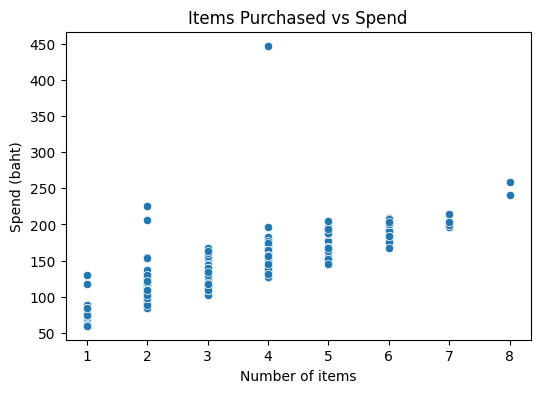

Pearson correlation r = 0.77


In [5]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='items', y='spend_baht')
plt.title("Items Purchased vs Spend")
plt.xlabel("Number of items")
plt.ylabel("Spend (baht)")
plt.show()

r = df[['items', 'spend_baht']].corr().iloc[0, 1]
print(f"Pearson correlation r = {r:.2f}")

### Interpretation prompts
Describe:
- **direction**
- **form**
- **strength**
- **unusual observations**

Then ask:

> Does correlation tell us that buying more items *causes* higher spending?

No. It describes association in this dataset.

## 6. Correlation Heatmap — Overview, Not Conclusion

Use a heatmap to decide **where to look next**.

,items,wait_time_min,spend_baht,satisfaction
items,1.00,-0.08,0.77,0.08
wait_time_min,-0.08,1.00,-0.13,-0.68
spend_baht,0.77,-0.13,1.00,0.14
satisfaction,0.08,-0.68,0.14,1.00


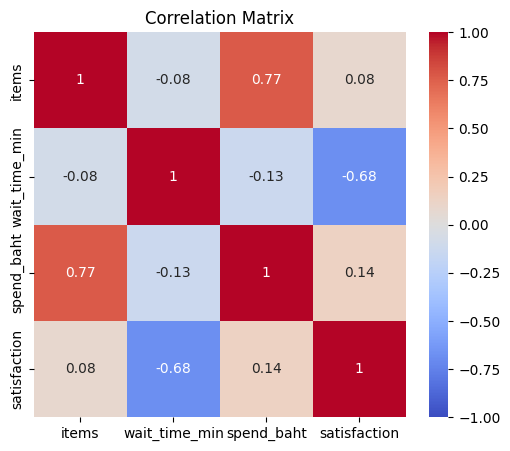

In [6]:
numeric_cols = ['items', 'wait_time_min', 'spend_baht', 'satisfaction']
corr = df[numeric_cols].corr().round(2)

display(corr)

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, vmin=-1, vmax=1, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### Teaching cue
A heatmap is a **map of possible follow-up questions**.

Pick one interesting pair and inspect the actual scatter plot before interpreting it.

## 7. Numerical + Categorical

**Question:** Do mobile and counter customers differ in waiting time?

First produce the grouped table using **Lecture 6 skills**.
Then visualize the same comparison.

,count,mean,median,std
channel,,,,
Counter,152,10.7,10.5,2.4
Mobile,88,7.3,7.0,2.7


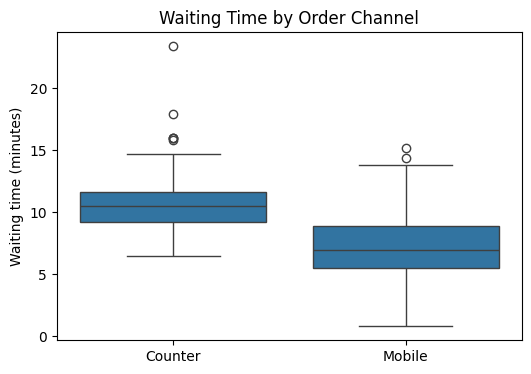

In [7]:
summary = (
    df.groupby('channel')['wait_time_min']
      .agg(['count', 'mean', 'median', 'std'])
      .round(1)
)
display(summary)

plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='channel', y='wait_time_min')
plt.title("Waiting Time by Order Channel")
plt.xlabel("")
plt.ylabel("Waiting time (minutes)")
plt.show()

### Bridge to Lecture 6
> You already know how to produce the grouped table.  
> The plot is its visual form — it helps us see spread, overlap, and unusual observations.

Ask:
- Are the medians different?
- How much overlap remains?
- Are the group sizes similar?

### Another View of the Same Comparison: Violin Plot

A **box plot** summarizes the median, quartiles, spread, and unusual observations.

A **violin plot** adds information about the **shape and density** of the distribution.

**Question:** Does the violin plot reveal anything about the waiting-time distributions that is less obvious in the box plot?

> **Teaching cue:** Use the violin plot as a follow-up view, not a replacement for the box plot.
>
> Ask students to compare:
> - center,
> - spread,
> - overlap between Counter and Mobile,
> - where observations are most concentrated,
> - whether either distribution appears skewed or has multiple dense regions.

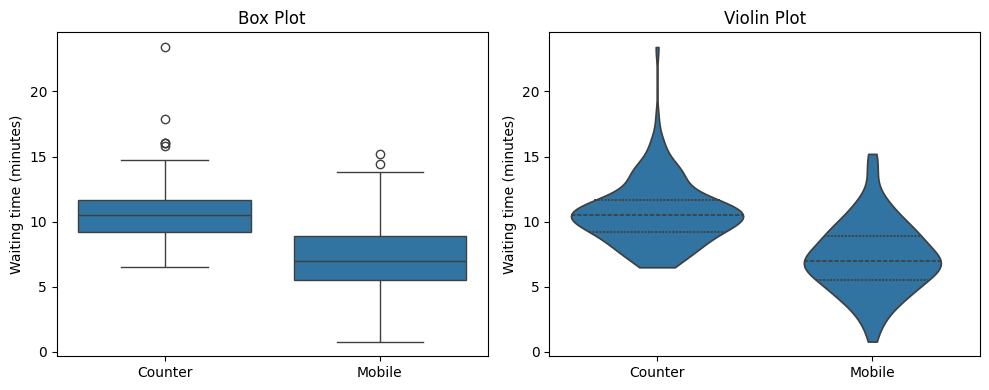

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Box plot: compact summary of center and spread
sns.boxplot(
    data=df,
    x='channel',
    y='wait_time_min',
    ax=axes[0]
)
axes[0].set_title('Box Plot')
axes[0].set_xlabel('')
axes[0].set_ylabel('Waiting time (minutes)')

# Violin plot: adds the shape/density of the distribution
sns.violinplot(
    data=df,
    x='channel',
    y='wait_time_min',
    inner='quartile',
    cut=0,
    ax=axes[1]
)
axes[1].set_title('Violin Plot')
axes[1].set_xlabel('')
axes[1].set_ylabel('Waiting time (minutes)')

plt.tight_layout()
plt.show()

### Quick interpretation prompt

Complete these statements before moving on:

- **Box plot tells me:** ______________________________________
- **Violin plot additionally shows:** ___________________________
- **My observation:** _________________________________________

**Key idea:** Different plots can answer the same question from different perspectives.  
Choose the view that makes the relevant pattern easiest to see.

## 8. Two Categorical Variables — Counts vs Proportions

**Question:** Does membership usage differ by order channel?

Raw counts and proportions answer different questions.

Counts


member,No,Yes
channel,,
Counter,80,72
Mobile,53,35


Row proportions


member,No,Yes
channel,,
Counter,0.526,0.474
Mobile,0.602,0.398


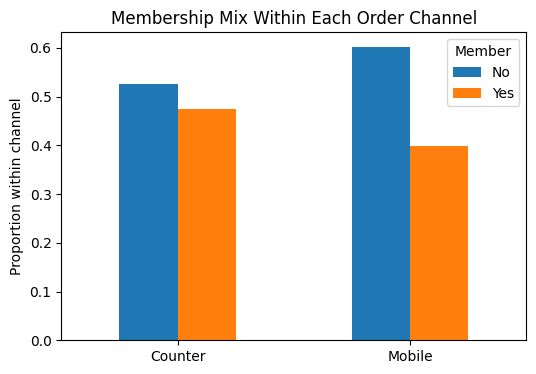

In [9]:
counts = pd.crosstab(df['channel'], df['member'])
props = pd.crosstab(df['channel'], df['member'], normalize='index').round(3)

print("Counts")
display(counts)

print("Row proportions")
display(props)

props.plot(kind='bar', figsize=(6, 4))
plt.title("Membership Mix Within Each Order Channel")
plt.ylabel("Proportion within channel")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(title="Member")
plt.show()

### Class question
Why might proportions be more informative than counts here?

Because the two channel groups have different total sizes.

## 9. Multivariate EDA — Add a Third Variable Only for a Reason

Start with:

**Question:** Is waiting time associated with satisfaction?

Then add `channel` because we want to know whether the pattern differs by order method.

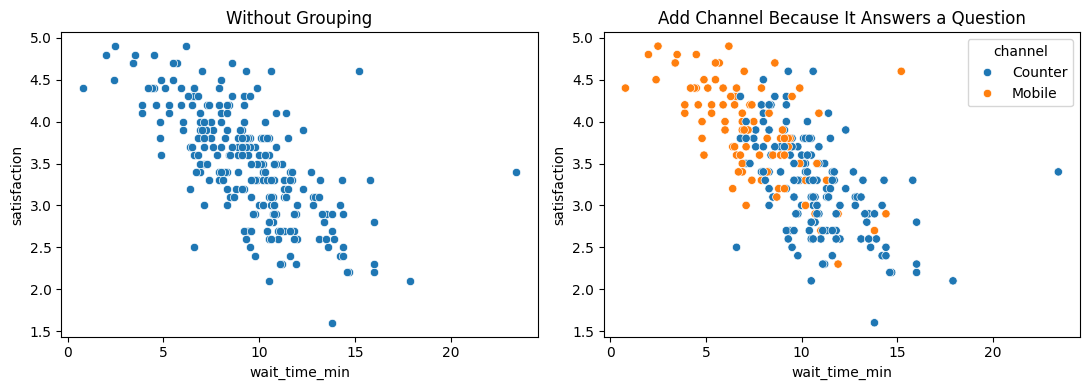

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.scatterplot(
    data=df,
    x='wait_time_min',
    y='satisfaction',
    ax=axes[0]
)
axes[0].set_title("Without Grouping")

sns.scatterplot(
    data=df,
    x='wait_time_min',
    y='satisfaction',
    hue='channel',
    ax=axes[1]
)
axes[1].set_title("Add Channel Because It Answers a Question")

plt.tight_layout()
plt.show()

### Follow-up: facet when grouping becomes hard to read

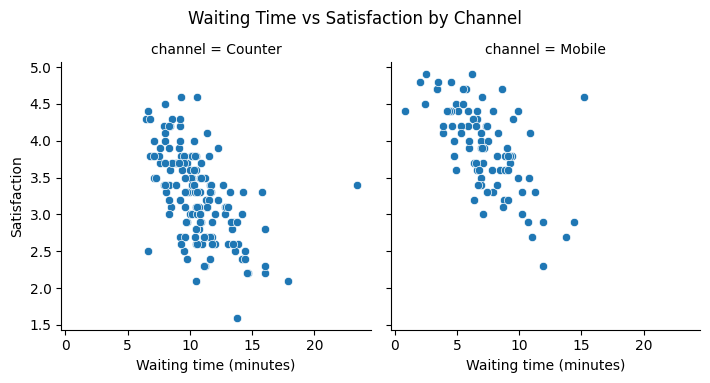

In [11]:
g = sns.relplot(
    data=df,
    x='wait_time_min',
    y='satisfaction',
    col='channel',
    height=3.6,
    aspect=1
)
g.set_axis_labels("Waiting time (minutes)", "Satisfaction")
g.fig.suptitle("Waiting Time vs Satisfaction by Channel", y=1.05)
plt.show()

## 10. From Plot to Insight

Use this three-step structure:

### Observation
What do you see? Be precise and evidence-based.

### Interpretation
What might explain it? Use cautious language.

### Next question
What should we investigate next?

### Example
**Observation:** Counter orders tend to have longer waiting times than mobile orders, although the distributions overlap.

**Interpretation:** Order channel may be associated with waiting experience, but lunch-period demand could also contribute.

**Next question:** Does the channel difference remain within each daypart?

## 11. One More Investigation

**Question:** Does the channel difference remain within each daypart?

This demonstrates how one EDA result leads naturally to the next question.

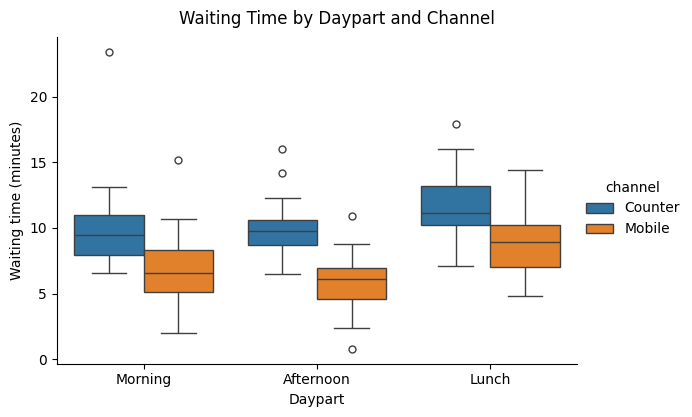

In [12]:
g = sns.catplot(
    data=df,
    x='daypart',
    y='wait_time_min',
    hue='channel',
    kind='box',
    height=4,
    aspect=1.5
)
g.set_axis_labels("Daypart", "Waiting time (minutes)")
g.fig.suptitle("Waiting Time by Daypart and Channel", y=1.03)
plt.show()

## 12. What EDA Can and Cannot Tell Us

EDA can help us:
- describe distributions,
- reveal associations and subgroups,
- identify unusual observations,
- generate follow-up questions.

EDA alone cannot:
- prove causation,
- establish that one feature is the *most important predictor*,
- tell us how well a pattern will generalize to unseen data,
- replace a formal statistical test or predictive evaluation.

### Exit question
> What pattern from today's demo would you test formally next — and why?